#### 2. Community detection using simulated annealing
Using the simulated annealing algorithm from assignment 2 to detect clusters and find the optimal number of blocks B.
Because the trivial solution to assign each node its individual cluster and to have B=n is to be avoided, we limit the number of blocks manually to n//2.

In [2]:
import pathpyG as pp
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import geopandas as gpd
import contextily as cx
import folium

DATA_DIR = os.path.abspath(os.path.join(os.getcwd(), "../../data/clean/"))

metadata = pd.read_csv(os.path.join(DATA_DIR, "streamflow_wy2022_metadata_all.csv"), dtype={"site_id": str, "huc8": str})

id_conversion = pd.read_csv('site_id_naming_reference.csv', dtype={'site_id': str})

metadata = metadata.merge(id_conversion[['site_id', 'site_rename']], on='site_id', how='left')
metadata['site_rename'] = metadata['site_rename'].str.replace(' ', '', regex=False)

metadata[['site_id', 'site_name', 'site_rename']]

graph_edges = [("site0", "site2"), 
              ("site1", "site2"),
              ("site2", "site6"),
              ("site3", "site6"),
              ("site4", "site6"),
              ("site5", "site6"),
              ("site6", "site8"),
              ("site7", "site8"),
              ("site8", "site9"),
              ("site9", "site11"),
              ("site10", "site11"),
              ("site11", "site13"),
              ("site12", "site13"),
              ("site13", "site15"),
              ("site14", "site15"),
              ("site15", "site17"),
              ("site16", "site17")] 


graph_edges02 = [("site18", "site21"),
              ("site19", "site20"),
              ("site20", "site21"),
              ("site21", "site26"),
              ("site22", "site26"),
              ("site23", "site26"),
              ("site24", "site26"),
              ("site25", "site26"),
              ("site26", "site27"),
              ("site27", "site30"),
              ("site28", "site29"),
              ("site29", "site30")]


graph_edges_all = graph_edges + graph_edges02 + [("site30", "site13")]
river_network = pp.Graph.from_edge_list(graph_edges_all).to_undirected()

In [3]:
from tqdm.notebook import tqdm
from collections import Counter, defaultdict
import scipy as sp

def log(x):
    if x == 0:
        return 0
    else:
        return np.log(x)

def SBM_max_likelihood(z, graph: pp.Graph):
    B = len(set(z))
    C = Counter(z)
    L = 0    
    E = np.zeros((B,B))
    N = np.zeros((B,B))
    
    for k in range(B):
        for l in range(B):
            # calculate possible links
            if k == l:
                N[k,l] = sp.special.binom(C[k], 2)
            else:
                N[k,l]= C[k] * C[l]
            for v,w in graph.edges:
                v_idx = graph.mapping.to_idx(v)
                w_idx = graph.mapping.to_idx(w)
                if v_idx < w_idx and ((z[v_idx] == k and z[w_idx] == l) or (z[v_idx] == l and z[w_idx] == k)):
                    E[k,l] += 1
    M = E / N
    M = np.nan_to_num(M) 
    for k in range(B):
        for l in range(k+1):
            L+= E[k,l] * log(M[k,l]+1e-12) + (N[k,l] - E[k,l]) * log(1-M[k,l]+1e-12)

    return L, M

def simulated_annealing_find_B(graph: pp.Graph, cooling_slowness = 5000, changes_per_iter=1, iterations=1000):
    temperatures = []
    likelihoods = []

    n = graph.n
    z = np.zeros(n, dtype=int)
    curr_best_l, M = SBM_max_likelihood(z, graph)

    for i in tqdm(range(iterations)):

        t = (1+cooling_slowness)/(i+1+cooling_slowness)
        z_copy = z.copy()

        if (np.random.rand() < 0.5 or len(set(z)) == 1) and len(set(z)) < n//4:
            block_to_split = np.random.choice(list(set(z)))
            members_of_block_to_split = np.where(z_copy == block_to_split)[0]
            if len(members_of_block_to_split) <= 1:
                continue
            np.random.shuffle(members_of_block_to_split)
            for node in members_of_block_to_split[:len(members_of_block_to_split)//2]:
                z_copy[node] = max(z) + 1
        else:
            block_to_merge_1, block_to_merge_2 = np.random.choice(list(set(z)), size=2, replace=False)
            z_copy[z_copy == block_to_merge_2] = block_to_merge_1

        current_labels = np.unique(z_copy)
        z_copy_renorm = np.zeros(len(z_copy), dtype=int)
        for idx, label in enumerate(current_labels):
            z_copy_renorm[z_copy == label] = idx
        

        l_new, M = SBM_max_likelihood(z_copy_renorm, graph)
        if l_new > curr_best_l or np.random.random() <= np.exp(-(log(curr_best_l+1e-12)-log(l_new+1e-12))/t):
            z = z_copy_renorm
            curr_best_l = l_new

        likelihoods.append(l_new)
        temperatures.append(t)

    return z, curr_best_l

def simulated_annealing(network: pp.Graph, B, cooling_slowness = 5000, changes_per_iter=1, iterations=1000):
    likelihoods = []
    n = network.n
    z = np.zeros(n, dtype=int)
    for i in range(n):
        z[i] = int(np.random.randint(B))
    l, m = SBM_max_likelihood(z, network)

    z_best = z.copy()
    l_best = l

    # we output the cooling temperatures to inspect the cooling schedule
    temperatures = []

    for i in tqdm(range(iterations)):

        t = (1+cooling_slowness)/(i+1+cooling_slowness)

        z_new = z.copy()

        for j in range(changes_per_iter):
            node_idx = np.random.choice(n)
            z_new[node_idx] = (z[node_idx] + np.random.randint(1, B)) % B
        l_new, m_new = SBM_max_likelihood(z_new, network)
        if l_new >= l:
            z = z_new
            l = l_new
            if l_new > l_best:       # only update best if truly the best seen
                z_best = z_new.copy()
                l_best = l_new
        elif np.random.random() <= np.exp(-(l-l_new)/t):
            z = z_new
            l = l_new

        likelihoods.append(np.exp(l))
        temperatures.append(t)
    return z_best, l_best, likelihoods, temperatures

np.random.seed(42)
z1, l_best, curr_best_l1, _ = simulated_annealing(river_network, 2, iterations=50000)
print("When fixing B to 3 the optimal z and likelihood as found through simulated annealing are: \n", z1, l_best)

z2, curr_best_l2 = simulated_annealing_find_B(river_network, iterations=50000)
print("finding B algorithm results, z and likelihoods:", z2, curr_best_l2)


  0%|          | 0/50000 [00:00<?, ?it/s]

When fixing B to 3 the optimal z and likelihood as found through simulated annealing are: 
 [0 0 0 0 0 0 0 0 0 0 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1 0 0 0 0 0 0] -93.31168768653586


  0%|          | 0/50000 [00:00<?, ?it/s]

/tmp/ipykernel_3599213/2651838886.py:9: RuntimeWarning: invalid value encountered in log
  return np.log(x)
/tmp/ipykernel_3599213/2651838886.py:30: RuntimeWarning: invalid value encountered in divide
  M = E / N


finding B algorithm results, z and likelihoods: [3 3 2 1 6 6 5 2 1 1 4 2 2 2 6 0 2 6 6 1 1 2 1 4 2 3 6 1 3 1 6] -101.09330611682712


our_likelihood =  (np.float64(-93.31168768653586), array([[0.11111111, 0.0042735 ],
       [0.0042735 , 0.15384615]]))


/tmp/ipykernel_3596064/1797785912.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap1 = plt.cm.get_cmap("tab10", len(community_ids1))


NameError: name 'z2' is not defined

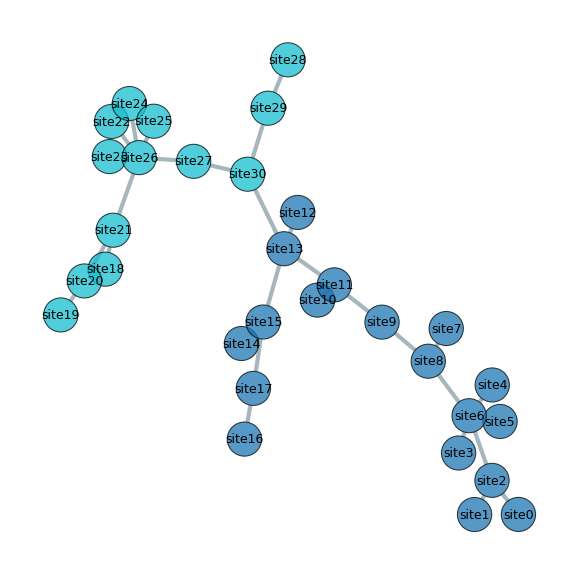

In [ ]:
#pp.config['visualisation']['default_backend'] = 'matplotlib'
group0 = ("site0", "site1", "site2", "site3", "site4", "site5", "site6", "site7", "site8", "site9", "site10", "site11", "site12", "site13", "site14", "site15", "site16", "site17")
group1 = ("site18", "site19", "site20", "site21", "site22", "site23", "site24", "site25", "site26", "site27", "site28", "site29", "site30")
our_z= []
for i, node in enumerate(river_network.nodes):
    if node in group0:
        our_z.append(0)
    elif node in group1:
        our_z.append(1)
our_likelihood = SBM_max_likelihood(our_z, river_network)
print("our_likelihood = ", our_likelihood)

community_ids1 = sorted(set(z1))
cmap1 = plt.cm.get_cmap("tab10", len(community_ids1))

color_dict1 = {
    community_id: cmap1(i)
    for i, community_id in enumerate(community_ids1)
}
pp.plot(river_network, node_color = [color_dict1[z1[river_network.mapping.to_idx(x)]] for x in river_network.nodes], node_label = [x for x in river_network.mapping.node_ids], filename="figures/sa_communities_B2_2.png", dpi=300);

community_ids2 = sorted(set(z2))
cmap2 = plt.cm.get_cmap("tab10", len(community_ids2))

color_dict2 = {
    community_id: cmap2(i)
    for i, community_id in enumerate(community_ids2)
}

pp.plot(river_network, node_color = [color_dict2[z2[river_network.mapping.to_idx(x)]] for x in river_network.nodes], node_label = [x for x in river_network.mapping.node_ids], filename="figures/sbm_communities_Bx_2.png", dpi=300);


##### Observations
Simulated annealing is not feasible to detect the community structure of our graph - even though 30 stream gauges does not appear prohibitively large, this number of stream gauges in our network is too big for a heuristic like simulated annealing to reliably find the optimum that we assign by hand.